# IEEE-CIS Fraud Detection — Explainability (SHAP)

## Goal
Explain the final LightGBM model's decisions — globally (which features matter most
and in which direction) and locally (why a specific transaction was flagged).

## Why this matters
- Regulators require explainability for automated financial decisions
- Fraud analysts need to know *why* a transaction was flagged before acting on it
- When the model is wrong, SHAP helps debug which feature drove the bad prediction

## Method: TreeSHAP
Exact Shapley values computed efficiently using the tree structure — `shap.TreeExplainer`.
Avoids the exponential cost of the general Shapley value calculation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
import shap
from sklearn.preprocessing import LabelEncoder

os.chdir('/Users/shaliqshukoor/fraud-risk-system')

# Load data
train_df = pd.read_parquet('data/processed/train_features.parquet')
val_df   = pd.read_parquet('data/processed/val_features.parquet')


with open('data/processed/selected_feature_names.json') as f:
    selected_features = json.load(f)
with open('models/optimal_threshold.json') as f:
    optimal_threshold = json.load(f)['optimal_threshold']

X_train = train_df[selected_features]
X_val   = val_df[selected_features]
y_val   = val_df['isFraud']

# Label encode object columns (fit on train, transform val)
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    ))

X_val_sel = X_val[selected_features]

# Load final model
model = joblib.load('models/lightgbm_final.pkl')

y_pred_proba = model.predict_proba(X_val_sel)[:, 1]
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

print(f'Validation rows: {len(X_val_sel):,}')
print(f'Features: {len(selected_features)}')
print(f'Using threshold: {optimal_threshold}')

/Users/shaliqshukoor/fraud-risk-system/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_8241/2829633423.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = le.fit_transform(X_train[col].astype(str))
/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_8241/2829633423.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

Validation rows: 147,635
Features: 412
Using threshold: 0.2


## Chapter 1 — Compute SHAP Values

Computing SHAP values for all 147,635 rows is unnecessary for exploration.
Use a random sample of 5,000 rows — large enough for stable global patterns,
fast enough to iterate.

In [2]:
sample_idx = X_val_sel.sample(n=5000, random_state=42).index
X_sample = X_val_sel.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classification, LightGBM TreeExplainer may return a single array
# (SHAP values for the positive/fraud class) or a list [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value (base rate, log-odds): {explainer.expected_value}')

SHAP values shape: (5000, 412)
Expected value (base rate, log-odds): -2.6980530049314053


/Users/shaliqshukoor/fraud-risk-system/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Chapter 2 — Global Summary Plot (Beeswarm)

X-axis: SHAP value — direction and magnitude of impact on the fraud prediction.
Color: feature value — red = high, blue = low.

A clean red-right/blue-left pattern means a simple, explainable relationship
(e.g. "higher TransactionAmt -> more likely fraud").

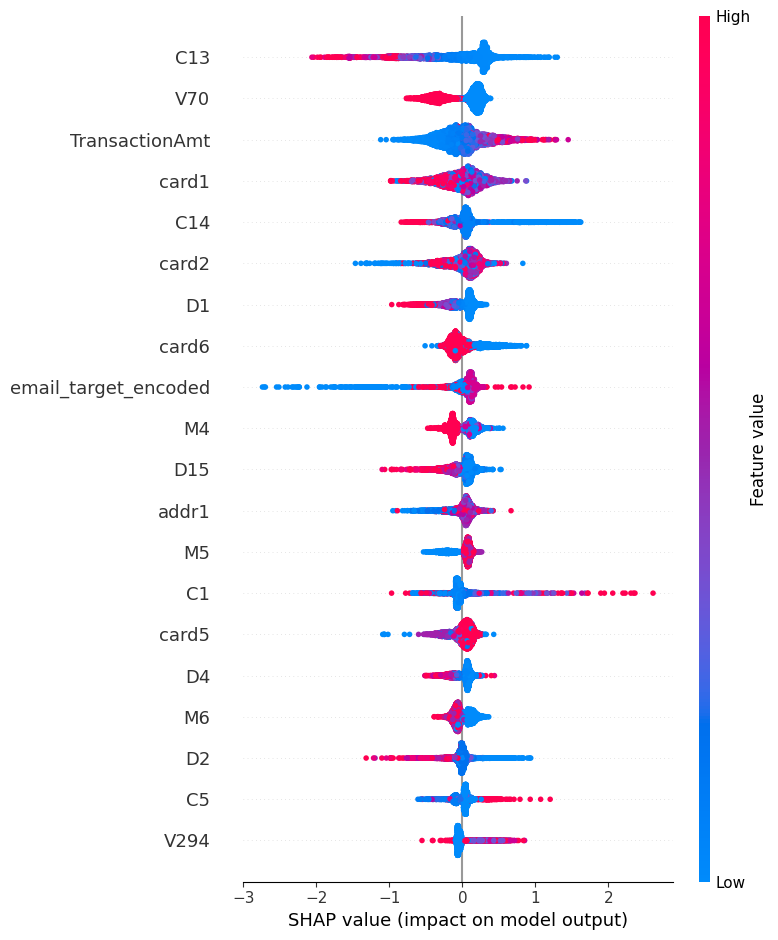

Saved to models/shap_summary.png


In [3]:
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig('models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/shap_summary.png')

## SHAP Explainability — Key Findings

- **The model's top risk drivers match known fraud patterns** — identity/device velocity (C-features), account/email reputation (`email_target_encoded`), recency of account activity (D-features), transaction amount, and card type. This is a strong sanity check that the model has learned *real* fraud signal, not noise or data artifacts.

- **The engineered `email_target_encoded` feature is performing as designed** — it shows one of the cleanest, most consistent relationships in the entire model: low-risk email domains push scores down, high-risk domains push scores up, with very little overlap. This validates the feature engineering effort.

- **No evidence the model relies on spurious or inappropriate signals** — every top driver has a clear, defensible business rationale, which supports model governance and audit requirements.

- **Explanations work at the individual transaction level too** — for any flagged transaction, we can generate a short "reason code" (e.g., *new account + high transaction amount + risky email domain*) that fraud analysts can use to speed up manual review.

- **This gives us a repeatable QA check** — by re-running this analysis after each retrain, we can quickly confirm the model's behavior hasn't drifted or started relying on something unexpected.

## Chapter 3 — Dependence Plots

For the top features, show how the SHAP value changes as the feature value changes.
Reveals thresholds, non-linearities, and interactions (color = interacting feature).

Top 3 features by mean |SHAP value|:
C13               0.369974
V70               0.252800
TransactionAmt    0.244914
dtype: float64


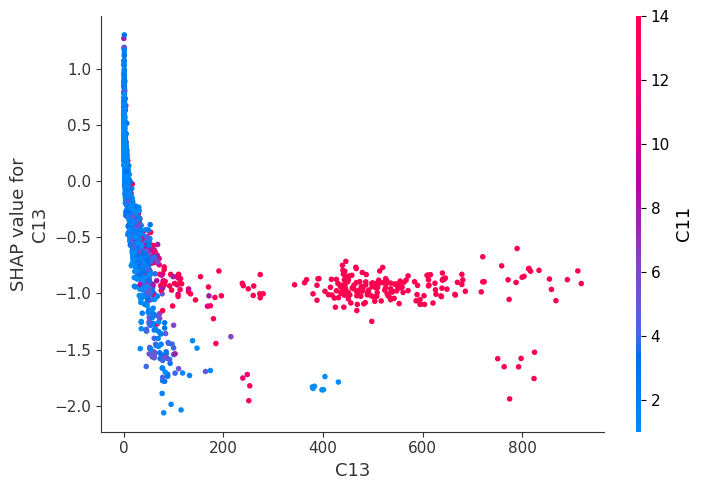

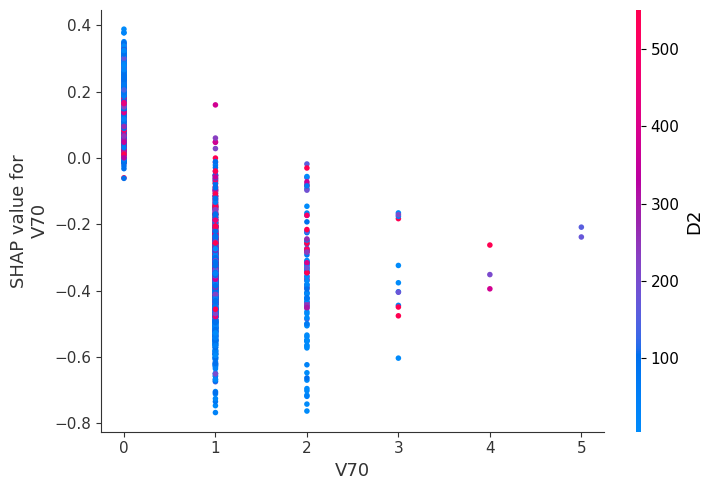

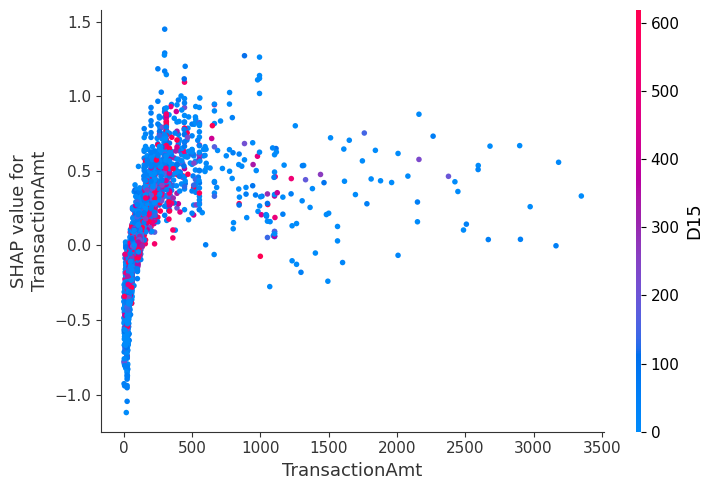

In [4]:
# Top 3 features by mean |SHAP value|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_abs_shap, index=selected_features).sort_values(ascending=False).head(3)
print('Top 3 features by mean |SHAP value|:')
print(top_features)

for feat in top_features.index:
    shap.dependence_plot(feat, shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig(f'models/shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

- **Mid range amount SHAP spikes to its highest a** — this is the danger zone since the points that are fraud are mid range transaction. They are the most suspicious ones 

## Chapter 4 — Local Explanations

Pick three specific transactions and explain each prediction individually:
1. A **True Positive** — correctly caught fraud
2. A **False Positive** — flagged but actually legitimate
3. A **False Negative** — missed fraud

These are the cases a fraud analyst or risk committee would ask about.

In [5]:
# Build a dataframe to find example cases within our SHAP sample
sample_pred = (model.predict_proba(X_sample)[:, 1] >= optimal_threshold).astype(int)
sample_df = pd.DataFrame({
    'y_true': y_val.loc[sample_idx].values,
    'y_pred': sample_pred
}, index=sample_idx)

tp_candidates = sample_df[(sample_df.y_true == 1) & (sample_df.y_pred == 1)]
fp_candidates = sample_df[(sample_df.y_true == 0) & (sample_df.y_pred == 1)]
fn_candidates = sample_df[(sample_df.y_true == 1) & (sample_df.y_pred == 0)]

print(f'TP candidates in sample: {len(tp_candidates)}')
print(f'FP candidates in sample: {len(fp_candidates)}')
print(f'FN candidates in sample: {len(fn_candidates)}')

TP candidates in sample: 150
FP candidates in sample: 800
FN candidates in sample: 33


--- True Positive (index 488471) ---
Predicted probability: 0.9950
Threshold: 0.2


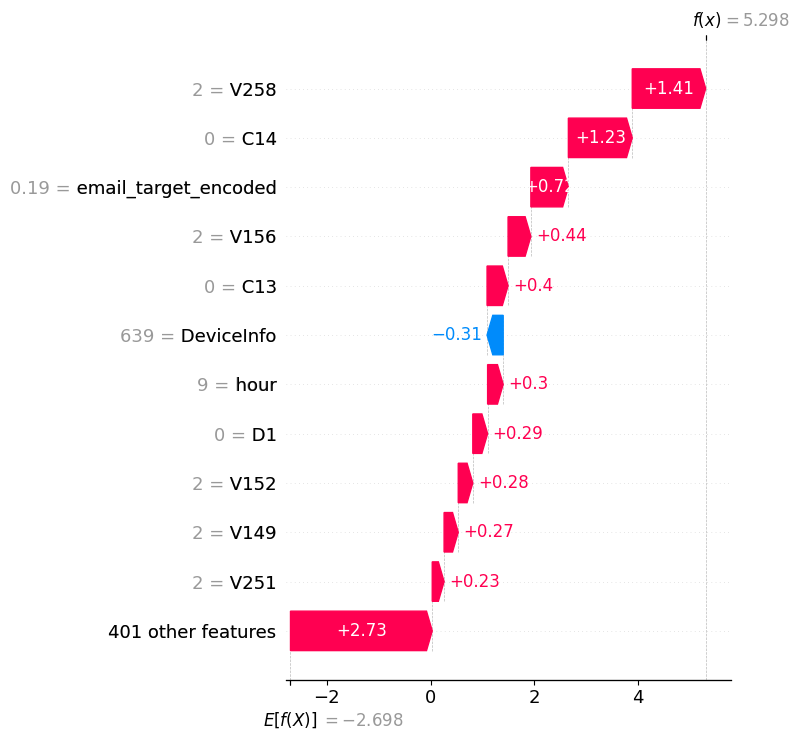

--- False Positive (index 498988) ---
Predicted probability: 0.2165
Threshold: 0.2


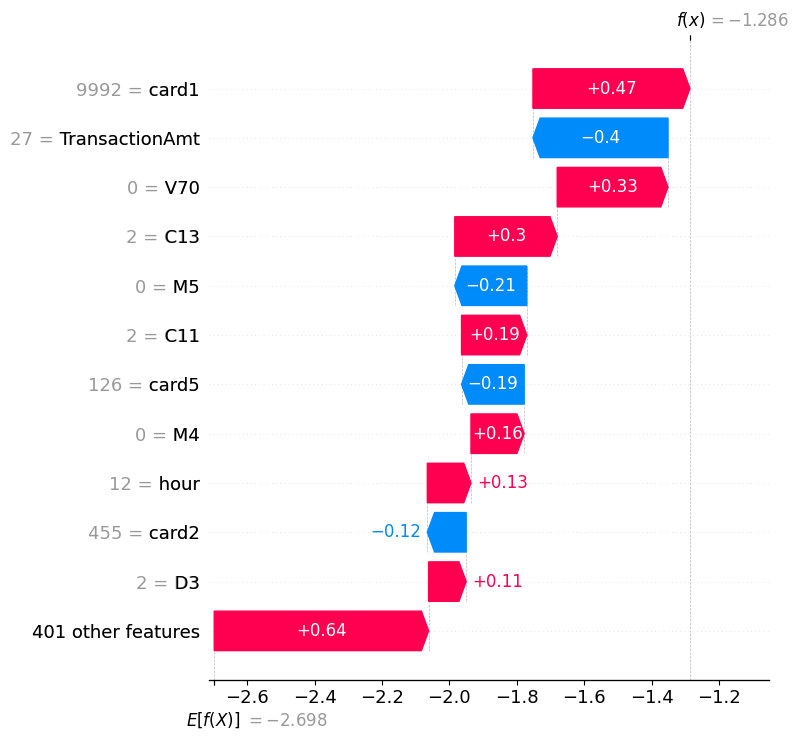

--- False Negative (index 537100) ---
Predicted probability: 0.1080
Threshold: 0.2


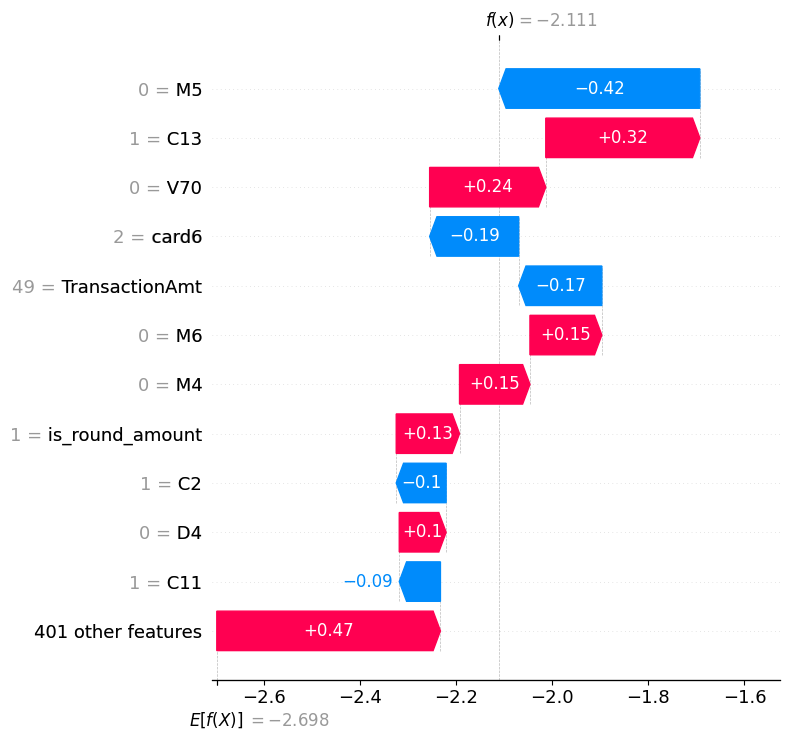

In [6]:
def explain_case(case_id, title):
    pos = X_sample.index.get_loc(case_id)
    print(f'--- {title} (index {case_id}) ---')
    print(f'Predicted probability: {model.predict_proba(X_sample.loc[[case_id]])[0, 1]:.4f}')
    print(f'Threshold: {optimal_threshold}')
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[pos],
            base_values=explainer.expected_value,
            data=X_sample.iloc[pos].values,
            feature_names=selected_features
        ),
        max_display=12, show=False
    )
    plt.tight_layout()
    plt.savefig(f'models/shap_waterfall_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

if len(tp_candidates) > 0:
    explain_case(tp_candidates.index[0], 'True Positive')
if len(fp_candidates) > 0:
    explain_case(fp_candidates.index[0], 'False Positive')
if len(fn_candidates) > 0:
    explain_case(fn_candidates.index[0], 'False Negative')

## Conclusion

### Sampling note
All SHAP values (summary plot, dependence plots, local explanations) were computed on a
random sample of **5,000 rows** out of 147,635 validation rows. This is large enough for
stable global patterns and fast enough to iterate — TreeSHAP on the full validation set
would be unnecessary for exploratory analysis.

### Global patterns
- `email_target_encoded` shows the cleanest monotonic relationship — low (historically
  safe) email domains push toward "not fraud", high (historically risky) domains push
  toward "fraud". Directly validates this engineered feature.
- `V258` is the single strongest individual driver (highest gain importance and largest
  SHAP magnitude in the True Positive case below).
- `C13`, `C14`, `V70` show **threshold/step effects** rather than smooth gradients —
  the model cares whether these counts are zero vs non-zero, not their exact magnitude.
- `TransactionAmt` has a non-monotonic, inverted-V relationship: very small and very
  large amounts look "safer" than mid-range amounts ($100-$1000), which look most
  suspicious.

### Local explanations — three cases
**1. True Positive (f(x)=5.298, p≈0.995)** — a "textbook fraud" case. Many independent
weak signals (`V258=2`, `C14=0`, `email_target_encoded=0.19`, several other V-features at
value 2) all agree in the same direction. Easy case for the model.

**2. False Positive (f(x)=-1.286, p≈0.216)** — a borderline crossing, just above the 0.20
threshold. A small legitimate transaction (`TransactionAmt=27`, which alone pushed
*toward* "not fraud") was outweighed by `card1=9992` (a card ID historically associated
with risk) and `V70=0`. The model's caution here is explainable, even though it was wrong.

**3. False Negative (f(x)=-2.111, p≈0.108)** — a fraud case that closely mimicked normal
behaviour. `M5=0` strongly pushed toward "not fraud" (-0.42), and `TransactionAmt=49` was
small and unremarkable. The only "tell" was `is_round_amount=1` (+0.13), which wasn't
enough to overcome the rest. This is the most valuable case for future iterations —
if this pattern (small round amounts + `M5=0`) recurs across multiple missed frauds,
it's a candidate for a new interaction feature.

### Why this matters
- Regulators and risk teams can see *exactly* why any given transaction was flagged or
  cleared — no black box.
- Borderline cases (like the FP above) can be reviewed by analysts with full context on
  what tipped the decision.
- Patterns in False Negatives directly inform the next round of feature engineering —
  explainability isn't just for compliance, it closes the loop on model improvement.